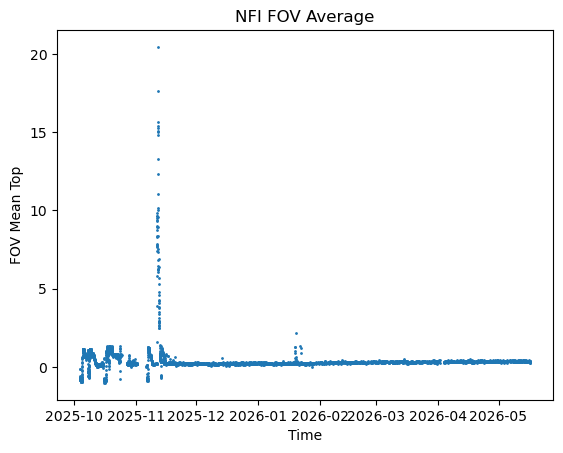

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset('products/NFI_FOV_AVG.nc')

plt.scatter(ds["time"].values, ds["fov_mean_top"].values, s=1)
plt.xlabel("Time")
plt.ylabel("FOV Mean Top")
plt.title("NFI FOV Average")
plt.show()

<xarray.DataArray 'time' ()> Size: 8B
[1 values with dtype=datetime64[ns]]
Coordinates:
    observation  datetime64[ns] 8B 2026-01-27T22:41:05


Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5395 ticks ([20365.166666666668, ..., 20589.916666666668]),

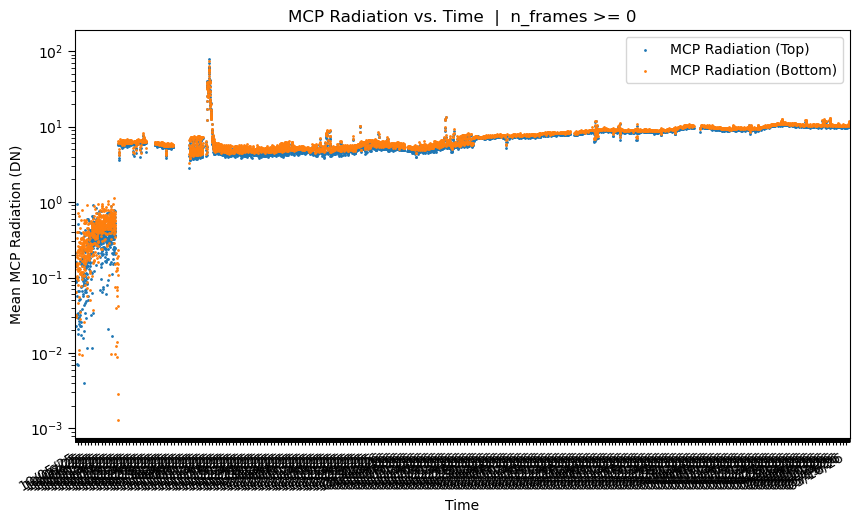

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from plotting import plot_data_vs_time
from avg import filter_time_range
from avg import filter_n_frames

ds = xr.open_dataset('products/WFI_FOV_AVG.nc')
mcp_rad_top = ds["fov_mean_top"].values
mcp_rad_bottom = ds["fov_mean_bottom"].values
print(ds["time"][3074])
start_datetime_str = '2024-10-05T00:00:00.000000'
end_datetime_str = '2026-10-16T00:00:00.000000'

# Convert the strings to datetime objects
start_datetime = np.datetime64(start_datetime_str)
end_datetime = np.datetime64(end_datetime_str)

n_frames_min = 0

mcp_rad_top = ds["fov_mean_top"].values
mcp_rad_bottom = ds["fov_mean_bottom"].values
datetimes = ds["time"].values
n_frames = ds["n_frames"].values
ds.close()

datetimes = datetimes.astype('datetime64[ns]')

# Filter data by time range
mcp_rad_top = filter_time_range(mcp_rad_top, datetimes, start_datetime, end_datetime)
mcp_rad_bottom = filter_time_range(mcp_rad_bottom, datetimes, start_datetime, end_datetime)
n_frames = filter_time_range(n_frames, datetimes, start_datetime, end_datetime)
datetimes = filter_time_range(datetimes, datetimes, start_datetime, end_datetime)

# Filter data by n_frames
mcp_rad_top = filter_n_frames(mcp_rad_top, n_frames, n_frames_min)
mcp_rad_bottom = filter_n_frames(mcp_rad_bottom, n_frames, n_frames_min)
datetimes_filtered = filter_n_frames(datetimes, n_frames, n_frames_min)


plot_data_vs_time(mcp_rad_top, mcp_rad_bottom, datetimes_filtered, n_frames_min, log=True)

plt.show()


In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import MultipleLocator

median_top_meds = np.load('products/column_bias_top_v2.npy')
median_bottom_meds = np.load('products/column_bias_bottom_v2.npy')

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(range(len(median_top_meds)), median_top_meds, s=1, alpha=1, label='Top Half Biases')
ax.scatter(range(len(median_bottom_meds)), median_bottom_meds, s=1, alpha=1, label='Bottom Half Biases')

ax.axhline(np.median(median_top_meds),
           color='blue',
           alpha=0.5,
           label=f'Median of Top Half Biases ({round(np.median(median_top_meds), 4)})')
ax.axhline(np.median(median_bottom_meds),
           color='orange',
           alpha=0.5,
           label=f'Median of Bottom Half Biases ({round(np.median(median_bottom_meds), 4)})')

ax.set_title('Column Voltage Biases, Top and Bottom Sensor Halves\n2025-10-04T00 to 2025-10-16T00\nWFI L1A-DRK Imagery')
ax.set_xlabel('Image Column')
ax.xaxis.set_major_locator(MultipleLocator(32))
ax.set_ylabel('Median Voltage Bias (DN n_frames$^{-1}$)')
ax.set_ylim(bottom=-2)

ax.legend(loc='lower center')
plt.show

FileNotFoundError: [Errno 2] No such file or directory: 'products/column_bias_top_v2.npy'

In [ ]:
import xarray as xr
ds = xr.open_dataset("data/WFI_1A-DRK/CARRUTHERS_GCI-WFI_L1A-DRK_20251112_v1.0.nc")

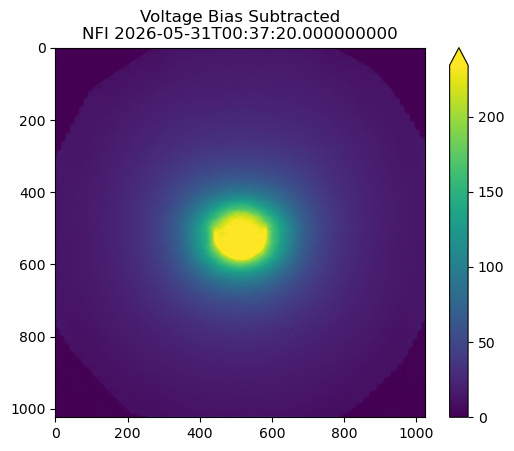

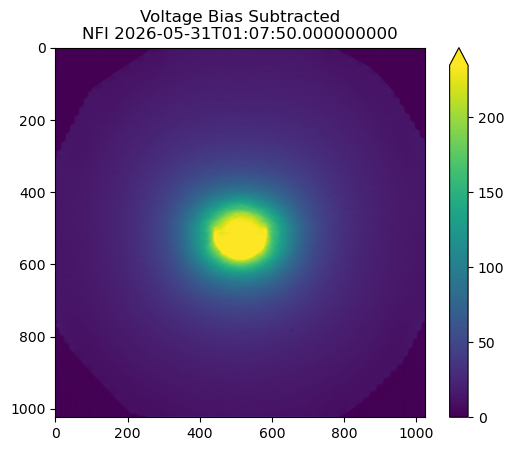

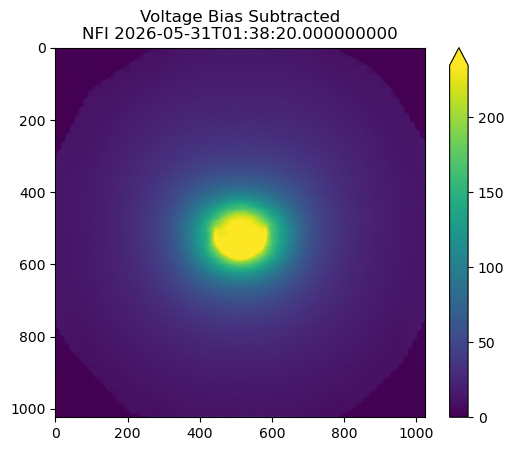

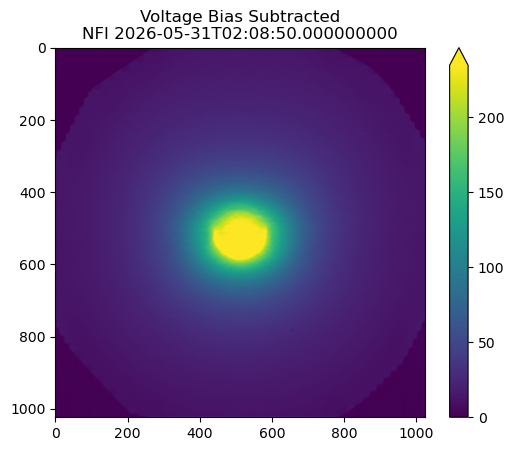

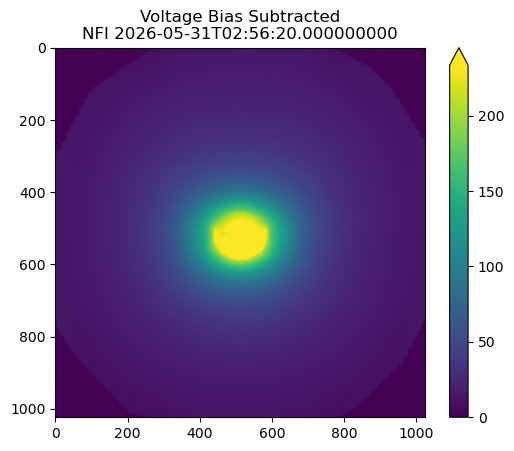

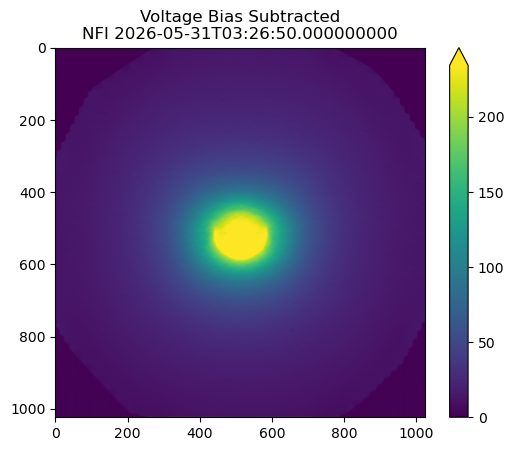

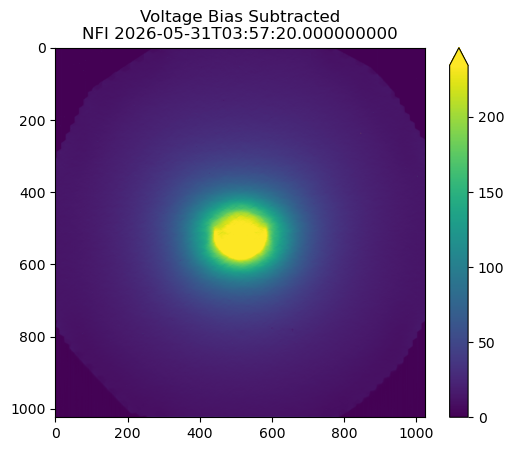

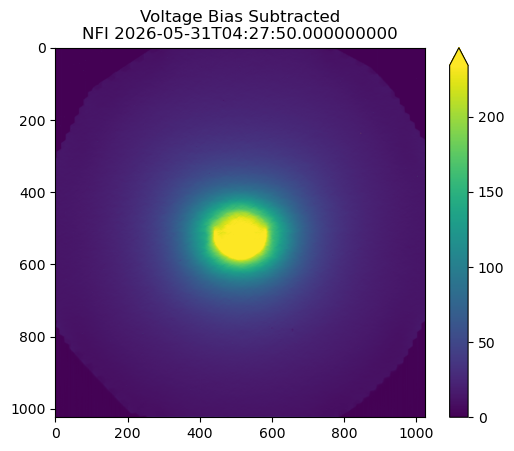

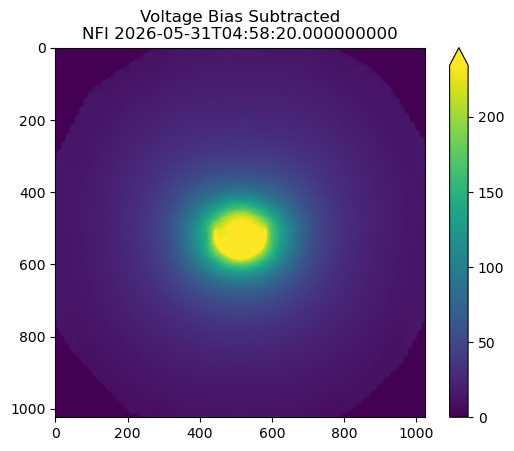

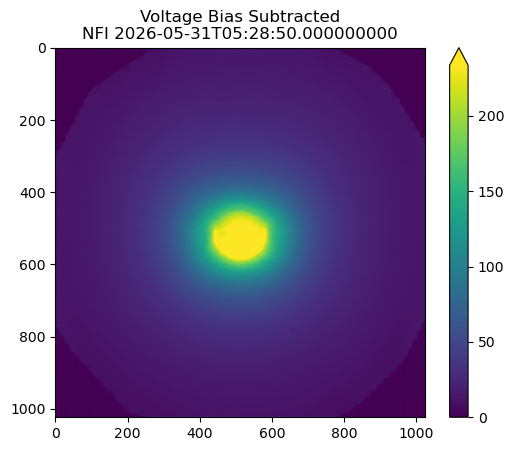

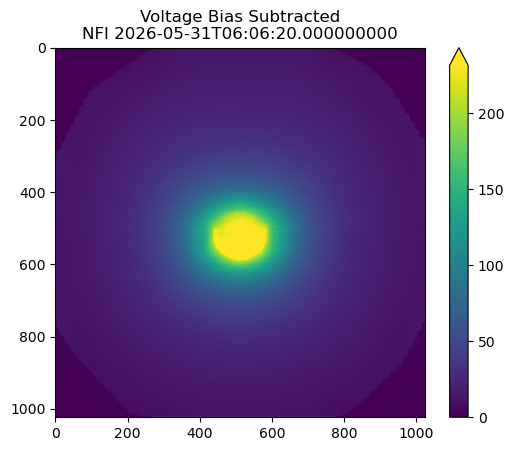

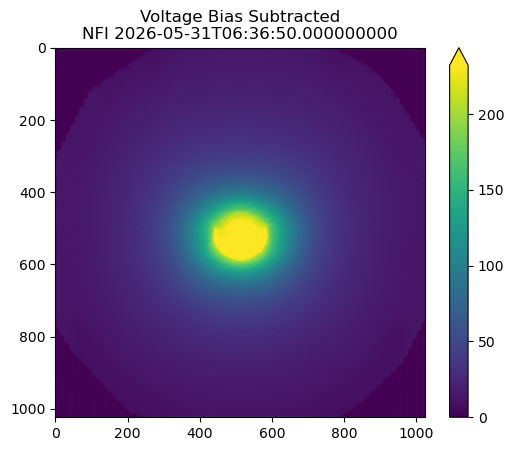

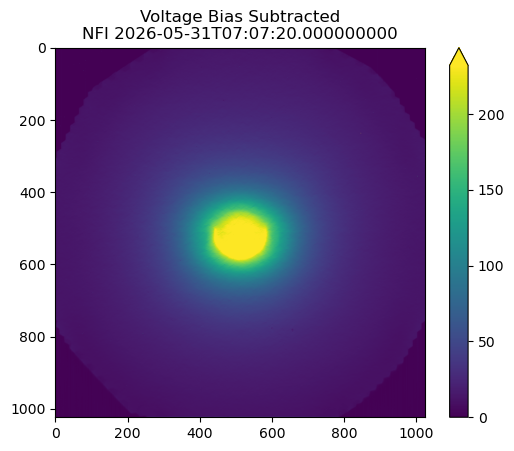

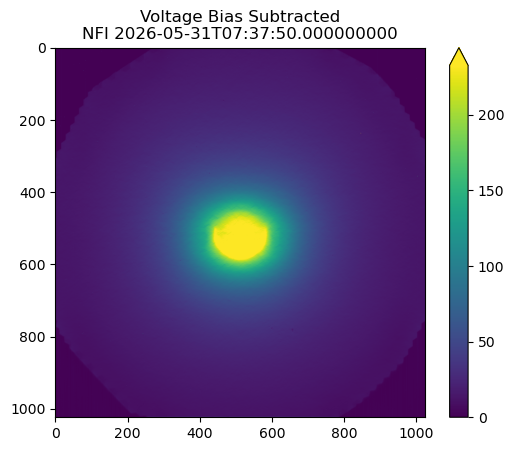

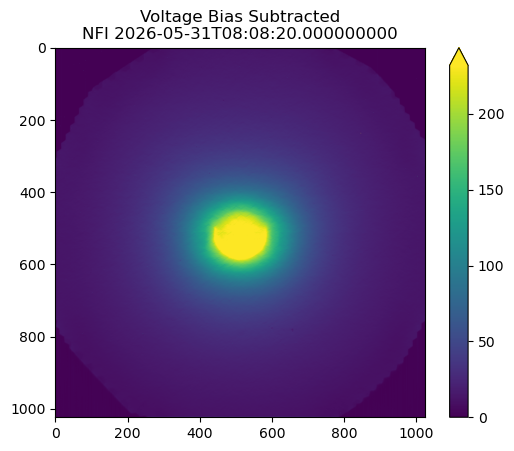

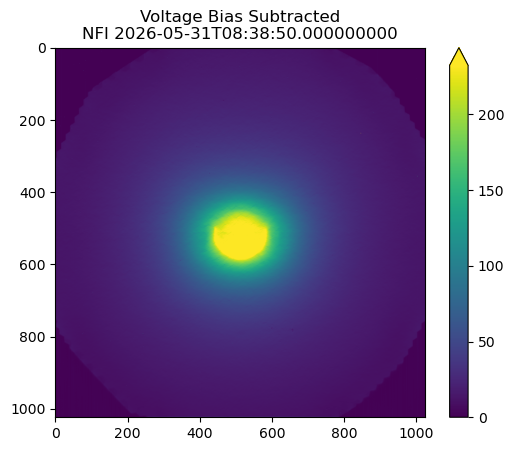

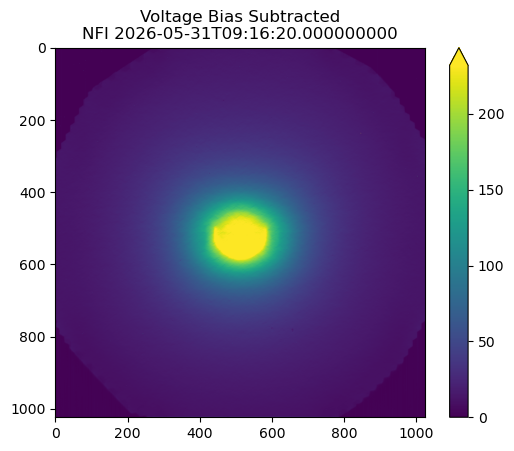

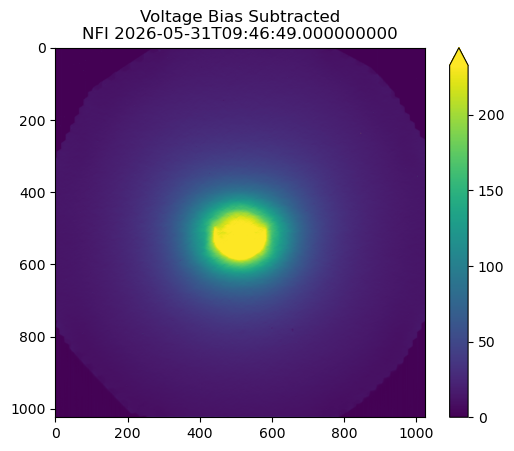

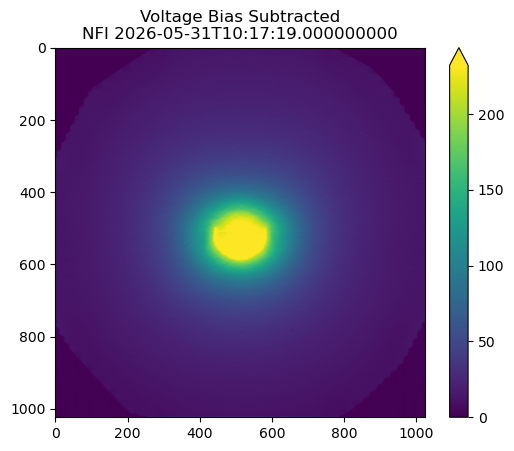

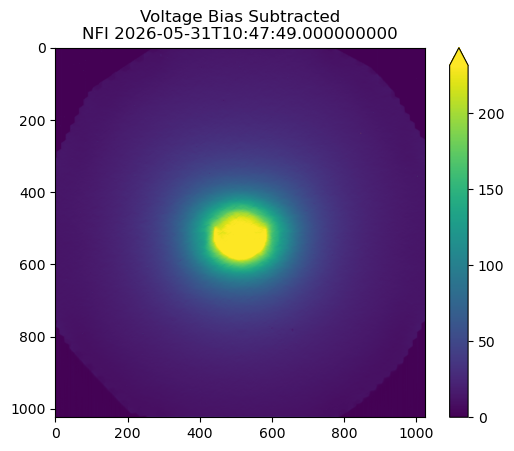

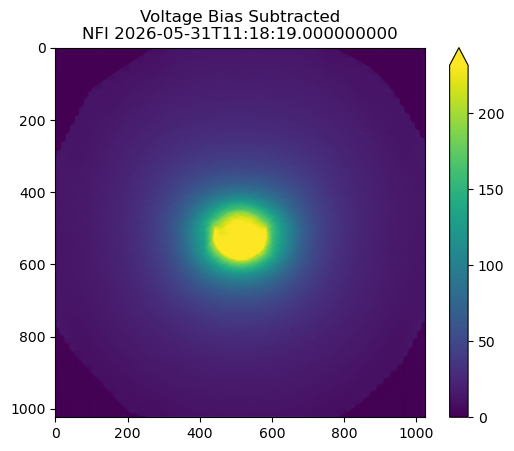

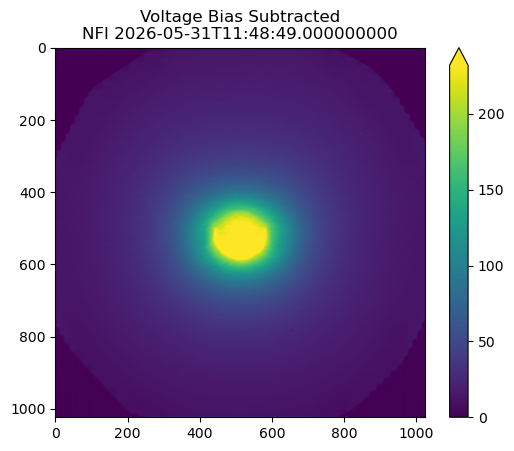

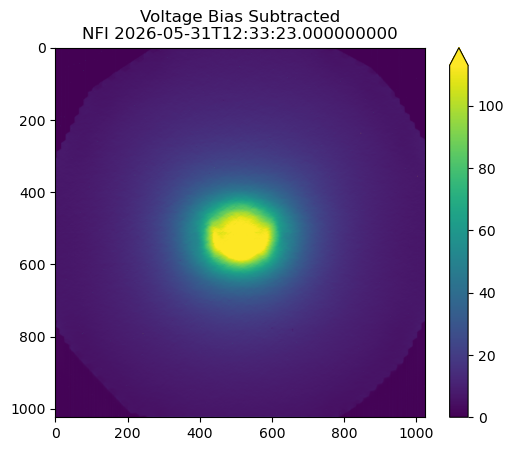

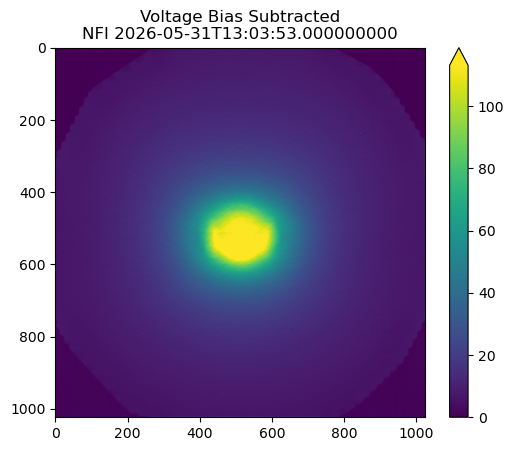

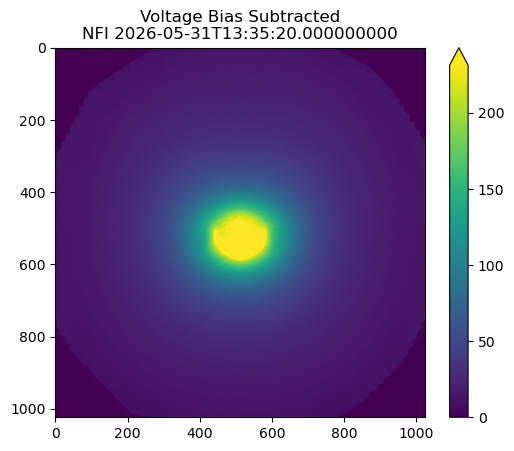

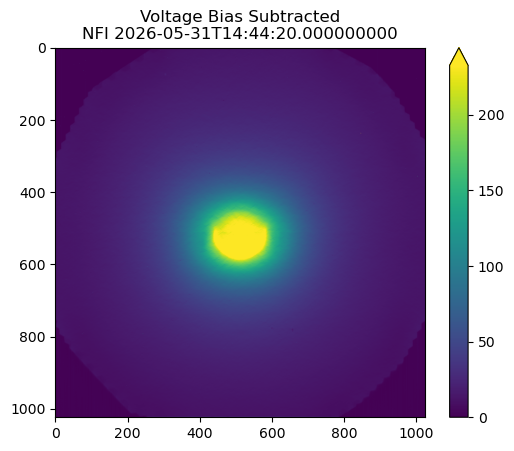

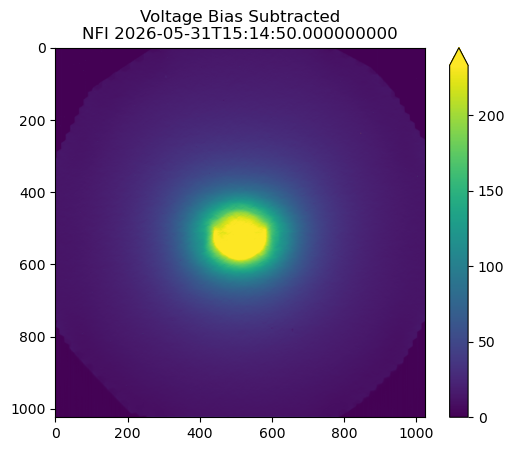

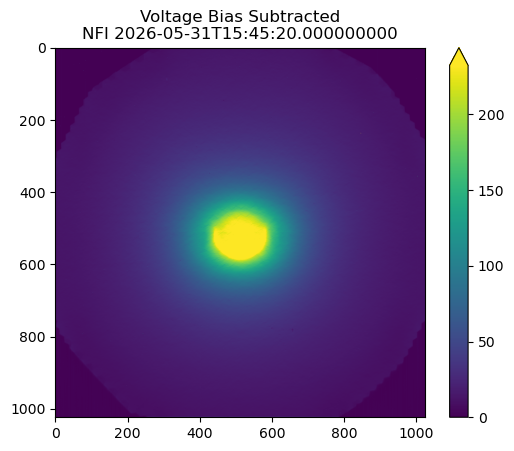

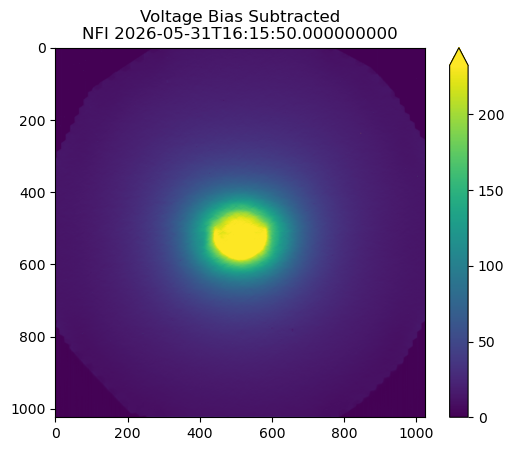

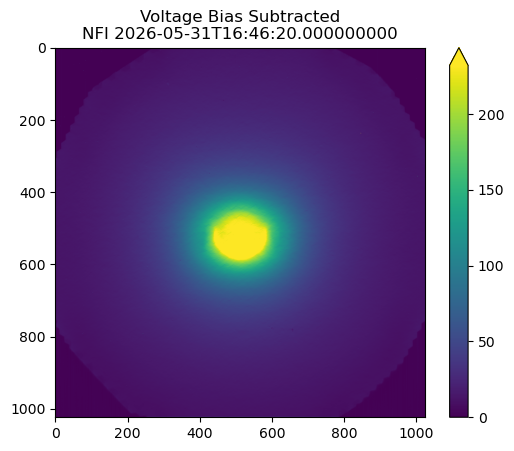

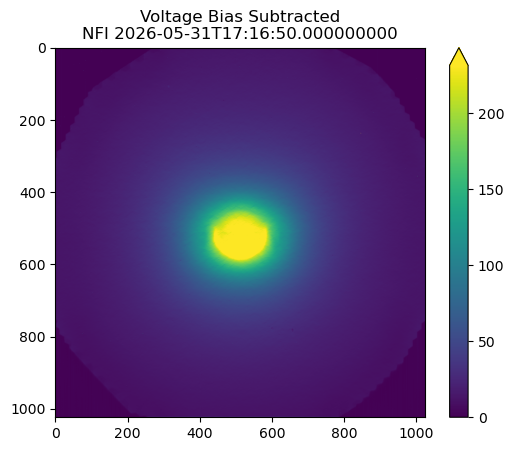

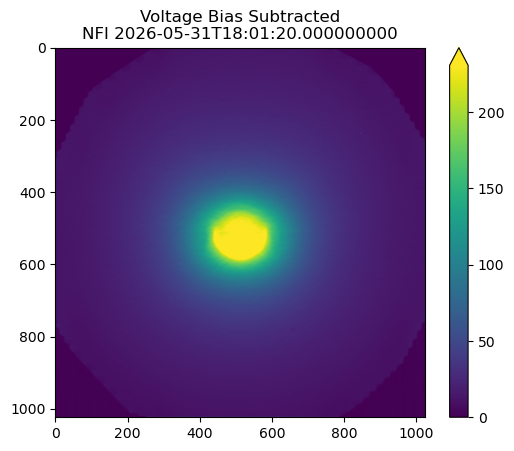

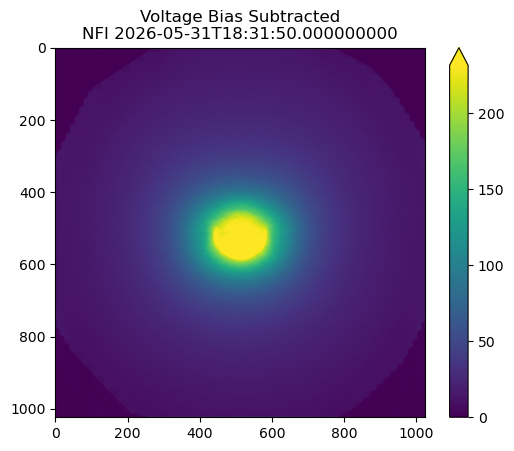

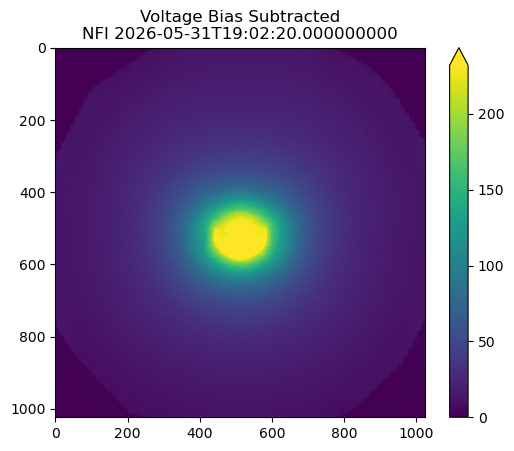

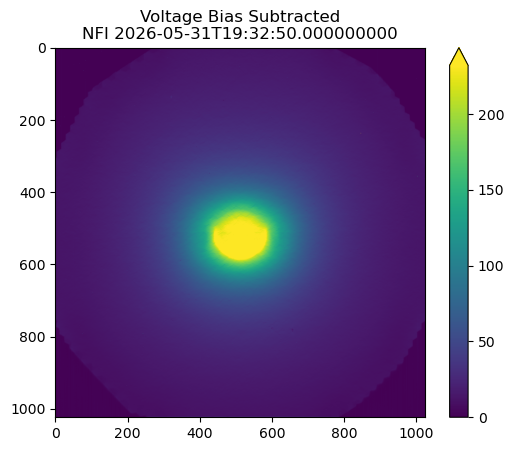

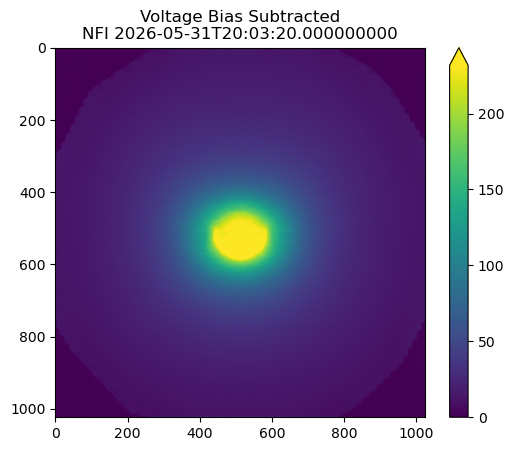

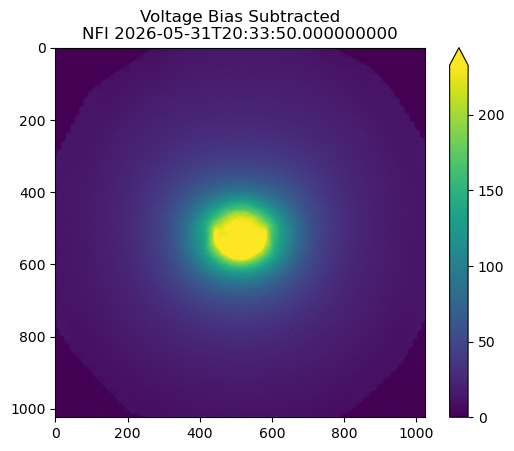

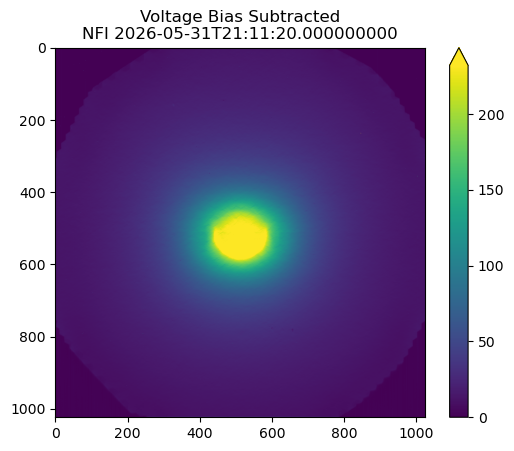

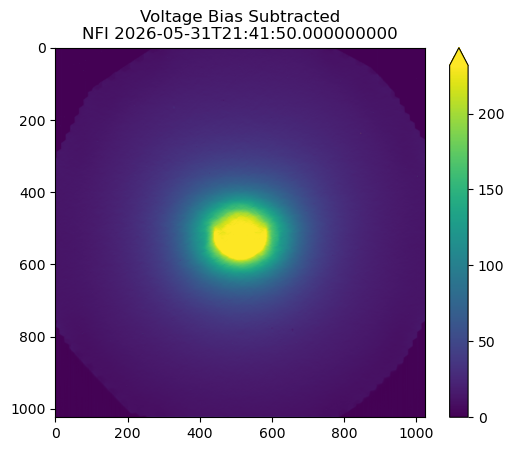

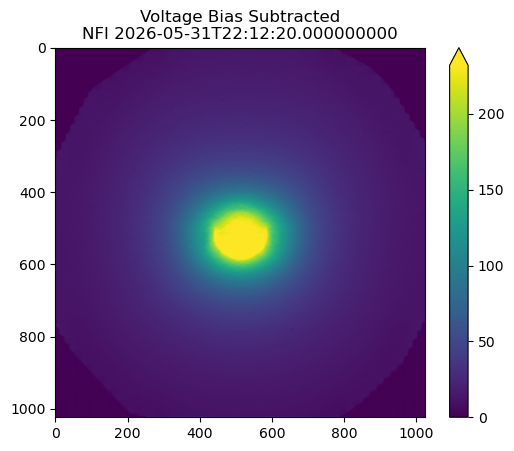

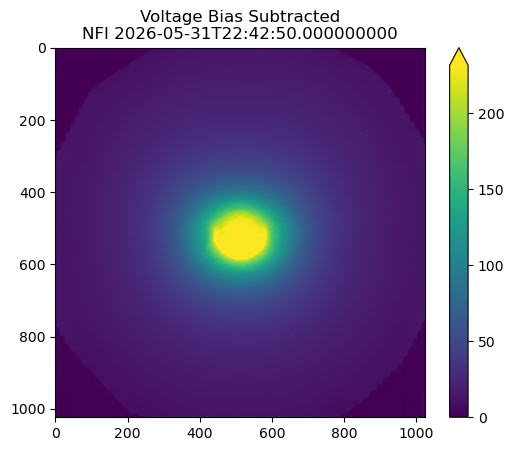

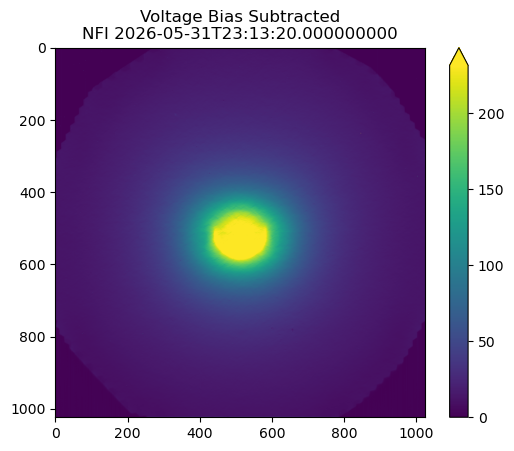

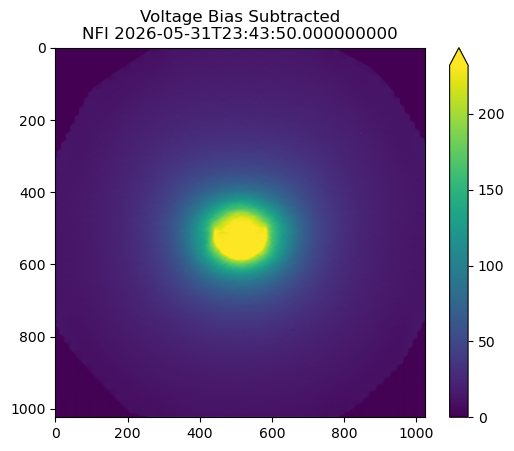

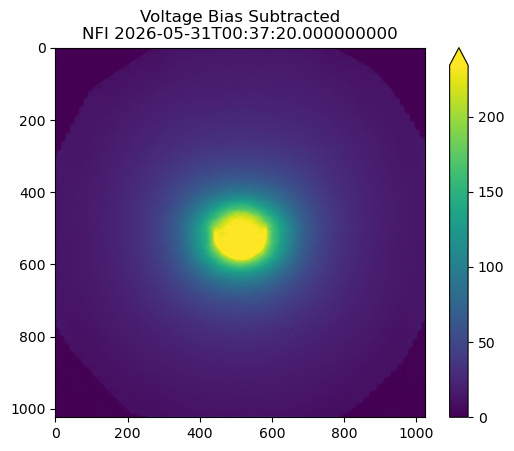

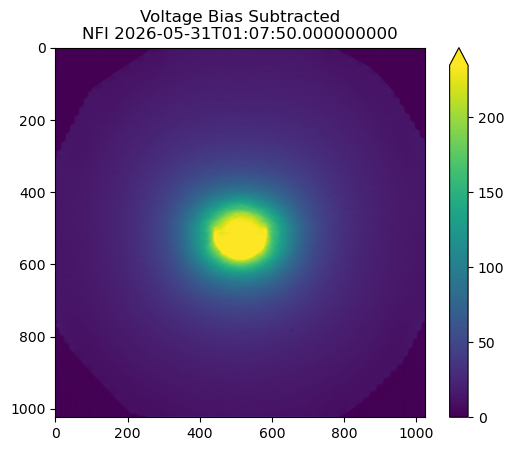

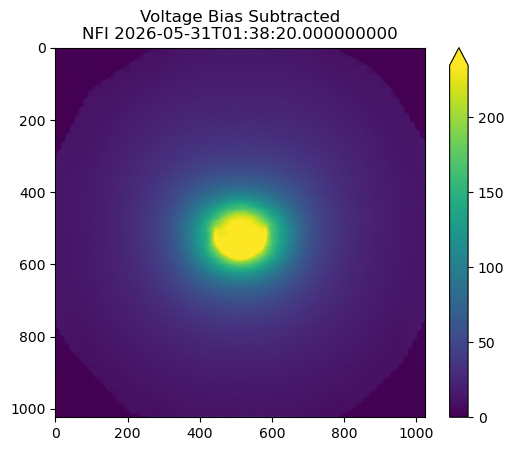

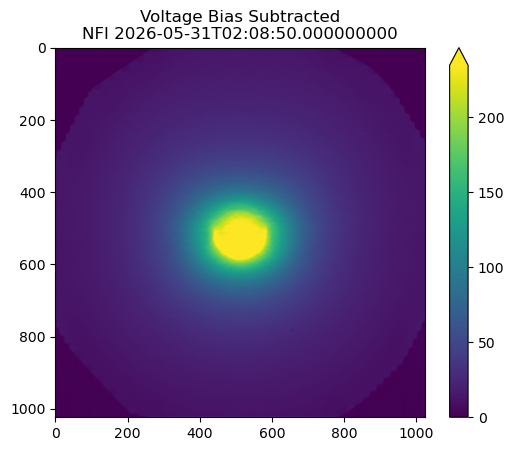

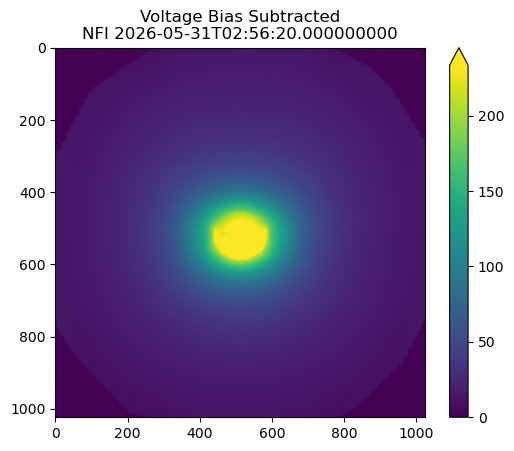

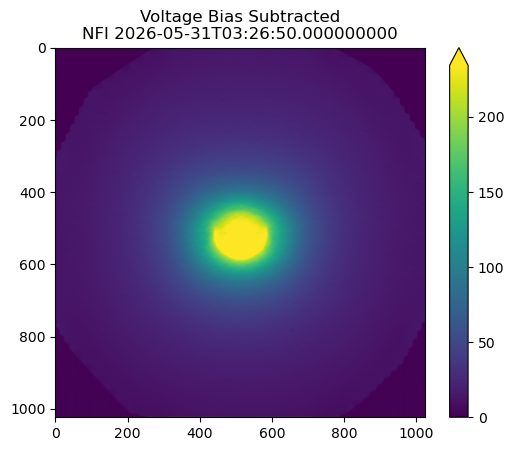

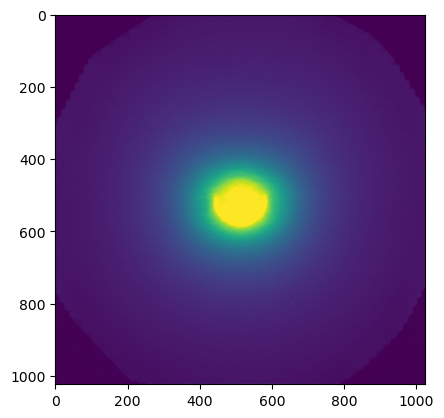

In [11]:
# VOLTAGE BIAS STRIPES REMOVAL DEMO

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glide.common_components.constants as constants
import glide.science_data_processing.L1A as L1A
from glide.calibration.bias_wavelet import wavelet_destripe
from glide.calibration.bias_wavelet import remove_dark_stripes

imager = "NFI"
'''
with xr.open_dataset(f"/carrdata/L1A/CARRUTHERS_GCI-{imager}_L1A-SCI_20260122_v1.0.nc") as ds:
    L1A_obj = L1A.L1A(ds)
images = L1A_obj.images
n_frames = L1A_obj.n_frames
times = L1A_obj.

corrected_images = np.zeros_like(images)
for i, image in enumerate(images):
    corrected_images[i], _ = wavelet_destripe(image, log=True)
'''
with xr.open_dataset("/carrdata/L1A/CARRUTHERS_GCI-NFI_L1A-SCI_20260531_v1.0.nc") as ds:
    L1A_drk = L1A.L1A(ds)

#images = images/n_frames[:, np.newaxis, np.newaxis]
drk_imgs = L1A_drk.images/L1A_drk.n_frames[:, np.newaxis, np.newaxis]
'''
1531
2025-11-12T01:25:09.000000000
'''

corrected_drkimages = np.zeros_like(drk_imgs)
for i, image in enumerate(drk_imgs):
    #corrected_drkimages[i], _ = remove_dark_stripes(image, "WFI")
    corrected_drkimages[i] = wavelet_destripe(image, log=True)[0]
    plt.imshow(corrected_drkimages[i,:,:], vmin=0, vmax=np.percentile(corrected_drkimages[i], 99))
    time = L1A_drk.time[i].astype(str)
    plt.title(f'Voltage Bias Subtracted\n{imager} {time}')
    plt.colorbar(extend='max')
    plt.show()


vvmax = np.percentile(drk_imgs, 99)
vvmax_corrected = np.percentile(corrected_drkimages, 99)

for i in range(6):
    plt.imshow(corrected_drkimages[i,:,:], vmin=0, vmax=np.percentile(corrected_drkimages[i], 99))
    time = L1A_drk.time[i].astype(str)
    plt.title(f'Voltage Bias Subtracted\n{imager} {time}')
    plt.colorbar(extend='max')
    plt.show()

    plt.imshow(corrected_drkimages[i,:,:], vmin=0, vmax=np.percentile(corrected_drkimages[i], 99))





In [ ]:
import numpy as np

top = np.load('products/column_bias_top.npy')
bottom = np.load('products/column_bias_bottom.npy')



print(np.mean(top), np.mean(bottom))

In [ ]:
import numpy as np
import numpy.linalg as la


# AIRPORT CONNECTIONS
def num_nodes_reachable(A, index, d):
    connections = np.zeros_like(A)
    for i in range(d):
        connections = connections + la.matrix_power(A, i)
    nodes_reachable = np.count_nonzero(connections[index, :])
    return nodes_reachable

network = np.array([[1, 1, 0, 0, 0],
                   [1, 1, 1, 0, 0],
                   [0, 1, 1, 1, 0],
                   [0, 0, 1, 1, 1],
                   [0, 0, 0, 1, 1]])

for num in range(4):
    print(f"{num}: ", num_nodes_reachable(network, 0, num))

In [ ]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# DCT BASIS



In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

oct4 = xr.open_dataset('data/WFI_1A-DRK/CARRUTHERS_GCI-WFI_L1A-DRK_20251112_v1.0.nc')
images = oct4['images']
n_frames = oct4['t_int']
times = oct4['time']

plt.imshow(images[6,:,:],vmin=0, vmax=250000/1.5)
plt.colorbar()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

plt.ion() # Turn on interactive mode
fig, ax = plt.subplots()
x, y = [], []
line, = ax.plot(x, y) # Get a reference to the line object
ax.set_ylim(0, 100) # Set fixed axis limits

for i in range(50):
    # Update data
    x.append(i)
    y.append(np.sin(i / 5) * 50 + 50) # Example dynamic data

    # Update the line object with new data
    line.set_xdata(x)
    line.set_ydata(y)

    # Rescale x-axis if needed (or set fixed limits beforehand)
    ax.set_xlim(0, i)

    # Redraw the canvas and process events
    fig.canvas.draw()
    fig.canvas.flush_events() # Process any queued GUI events
    time.sleep(0.01) # Small pause for visualization

In [ ]:
# Source - https://stackoverflow.com/a/193539
# Posted by Jeremy Cantrell, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-13, License - CC BY-SA 3.0
import glide.science_data_processing.L1A as L1A
from pprint import pprint
import xarray as xr

with xr.open_dataset("/data/L1A/CARRUTHERS_GCI-WFI_L1A-DRK_20251112_v1.0.nc", engine='netcdf4') as data:
    l1a_obj = L1A.L1A(data)
scraft = l1a_obj.scrafts[1]
pprint(dir(l1a_obj))
print(l1a_obj.activity_block)
print(l1a_obj.cam_modes)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'activity_block',
 'bias',
 'cam_modes',
 'cam_specs',
 'channel',
 'data',
 'distortion_correct',
 'drop_vars',
 'extreme_pixel_map',
 'filters',
 'high_rad',
 'im_modes',
 'images',
 'instr_bkgd_subtraction',
 'is_low_rad',
 'low_rad',
 'mask_cnr',
 'mask_cnr_r',
 'mask_corners',
 'mask_fov',
 'mask_fov_r',
 'mean_dark',
 'n_frames',
 'n_images',
 'nearest_dark',
 'nearest_ims',
 'npix',
 'register_images',
 'remove_flat',
 'scrafts',
 'select_filter',
 'stack',
 'stack_flat',
 't_int',
 't_op',
 'temp',
 'time']
